# Speech Emotion Recognition — Speech Transformers & Self-Supervised Learning (SSL) Models

**Notebook 4 of 4** in the RAVDESS series.

| Notebook | Focus |
|----------|-------|
| 1 | Classical ML on hand-crafted features (MFCCs, Chroma, Spectral) |
| 2 | CNN on mel-spectrograms — regularization, augmentation, transfer learning |
| 3 | CNN + sequential and attention modules — BiLSTM, Attention Pooling, MHSA |
| **4** | **Speech Transformers & Self-Supervised Learning (SSL) Models — Wav2Vec 2.0, HuBERT, WavLM, Whisper** |

### Research Question

> How do modern Self-Supervised Learning (SSL) speech representation models compare to standard 2D image CNNs for Speech Emotion Recognition, both in zero-shot feature extraction and fine-tuned settings?

In Notebook 2, we saw that transfer learning from an ImageNet-pretrained 2D CNN (ResNet18) reached **87.04%** accuracy. However, visual spectrogram representations lack speech-specific priors. This notebook evaluates models pre-trained on raw speech waveforms (SSL models) to test if learning from raw audio waveforms improves classification.

### Models Evaluated

| # | Model | Pre-training Paradigm | Key Advantage |
|---|-------|-----------------------|---------------|
| 1 | **Wav2Vec 2.0** | Contrastive predictive coding | Pioneer of raw audio SSL representations |
| 2 | **HuBERT** | Masked Language Modeling over K-Means units | Learns clean phonetic and acoustic codebooks |
| 3 | **WavLM** | Masked MLM + speech denoising / speaker overlap simulation | State-of-the-Art for prosody & speaker traits |
| 4 | **Whisper** | Large-scale supervised multitasking | Supervised baseline trained on 680k hours of audio |

### Evaluation Framework

For each model, we will perform two tests:
1. **Frozen Encoder (Zero-Shot Linear Probing)**: We freeze the pre-trained backbone, extract frame-level sequence embeddings, and train a shallow classification head on top. This tests the quality of the frozen representation.
2. **Full Fine-Tuning**: We unfreeze the backbone weights and train the entire network end-to-end to adapt the representations directly to emotional classification.

## 0. Environment Setup

Installs Hugging Face's `transformers`, `datasets`, and audio-processing libraries like `soundfile` and `librosa`.

In [1]:
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.7.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 181.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 240.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 226.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 66.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 82.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 119.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 177.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 138.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 109.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 81.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 63.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 107.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install transformers datasets accelerate soundfile -q

In [3]:
import os
import random
import warnings
import json

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading & Resampling (16kHz)

> **Crucial Acoustic Note**: Speech Transformers (Wav2Vec 2.0, HuBERT, WavLM) are pre-trained on speech sampled at **16,000 Hz**. In previous notebooks, audio was processed at 22,050 Hz. We resample all audio to 16,000 Hz to prevent domain shift and severe model degradation.

In [4]:
# Configuration
TARGET_SR = 16000
DURATION = 4  # seconds
MAX_SAMPLES = TARGET_SR * DURATION
data_source_path = '/kaggle/input'
if not os.path.exists(data_source_path):
    data_source_path = './data'

# Scan Directory for WAV files
wav_files = []
for dirname, _, filenames in os.walk(data_source_path):
    for filename in filenames:
        if filename.endswith('.wav'):
            wav_files.append(os.path.join(dirname, filename))

print(f"Total audio files found: {len(wav_files):,}")

# Map RAVDESS Codes to Emotion Labels
EMOTIONS_MAP = {
    "01": "neutral",  "02": "calm",     "03": "happy",
    "04": "sad",      "05": "angry",    "06": "fearful",
    "07": "disgust",  "08": "surprised"
}

def get_emotion(path: str) -> str:
    code = os.path.basename(path).split("-")[2]
    return EMOTIONS_MAP.get(code, "unknown")

columns = {
    "path": wav_files,
    "emotion": [get_emotion(path) for path in wav_files]
}

df = pd.DataFrame(columns)
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
print(f"Dataset shape: {df.shape}")

# Load & Resample Waveforms to 16,000 Hz in RAM
X_raw = []
for path in tqdm(df["path"], desc="Loading raw waveforms at 16kHz"):
    signal, sr = librosa.load(path, sr=TARGET_SR)
    if len(signal) < MAX_SAMPLES:
        signal = np.pad(signal, (0, MAX_SAMPLES - len(signal)))
    else:
        signal = signal[:MAX_SAMPLES]
    X_raw.append(signal)

X_raw = np.array(X_raw, dtype=np.float32)

# Encode Class Labels
encoder = LabelEncoder()
y = encoder.fit_transform(df["emotion"])
classes = list(encoder.classes_)
print(f"Loaded {len(X_raw)} waveforms of shape {X_raw.shape[1]:,}. Target classes: {classes}")

# Create Stratified Train / Val / Test Splits (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f"Train samples: {X_train.shape[0]} | Val samples: {X_val.shape[0]} | Test samples: {X_test.shape[0]}")

Total audio files found: 1,440
Dataset shape: (1440, 2)


Loading raw waveforms at 16kHz: 100%|██████████| 1440/1440 [00:34<00:00, 42.26it/s]


Loaded 1440 waveforms of shape 64,000. Target classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Train samples: 1008 | Val samples: 216 | Test samples: 216


## 2. Shared Evaluation & Fine-Tuning Pipeline

Common utilities to handle frozen feature extraction, training loops, early stopping, and zero-shot probing across all 4 architectures.

In [5]:
import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

# -------------------------------------------------------------
# Hardware Acceleration & cuDNN Optimizations
# -------------------------------------------------------------
torch.backends.cudnn.benchmark = False  # Dramatically speeds up fixed-shape audio models on T4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device} | Available GPUs: {num_gpus}")
if num_gpus > 1:
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

def wrap_multi_gpu(model):
    """Wraps model in DataParallel if multiple GPUs are detected."""
    if torch.cuda.device_count() > 1:
        return nn.DataParallel(model)
    return model

def unwrap_model(model):
    """Safely unrolls DataParallel wrapper for checkpoint saving & inference."""
    return model.module if hasattr(model, "module") else model


results = {}  # Store results: results[model_name] = {'train_acc': ..., 'test_acc': ..., 'gap': ...}

# -------------------------------------------------------------
# Custom Dataset Wrapper
# -------------------------------------------------------------
class AudioDataset(Dataset):
    """Plain dataset — shape (raw_waveform,)."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        
    def __len__(self):  
        return len(self.X)
        
    def __getitem__(self, idx): 
        return self.X[idx], self.y[idx]

# Dynamic Hugging Face Collator Generator
def make_collate_fn(processor, model_type="ssl"):
    def collate_fn(batch):
        waveforms = [item[0].numpy() for item in batch]
        labels = [item[1].item() for item in batch]
        
        if model_type == "whisper":
            # Whisper explicitly expects padding to 30 seconds (3000 mel frames)
            inputs = processor(
                waveforms, 
                sampling_rate=16000, 
                return_tensors="pt", 
                padding="max_length"  # <--- CRITICAL FOR WHISPER!
            )
            return {
                "input_features": inputs.input_features,
                "labels": torch.tensor(labels, dtype=torch.long)
            }
        else:
            inputs = processor(waveforms, sampling_rate=16000, padding=True, return_tensors="pt")
            batch_dict = {
                "input_values": inputs.input_values,
                "labels": torch.tensor(labels, dtype=torch.long)
            }
            if "attention_mask" in inputs:
                batch_dict["attention_mask"] = inputs.attention_mask
            return batch_dict
            
    return collate_fn


def count_parameters(model):
    base = unwrap_model(model)
    trainable_params = sum(p.numel() for p in base.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in base.parameters())
    print(f"Trainable Parameters: {trainable_params:,} | Total Parameters: {total_params:,} | Trainable %: {100 * trainable_params / total_params:.4f}%")

# -------------------------------------------------------------
# High-Throughput Multi-GPU Training Loop
# -------------------------------------------------------------
def train_model(model, train_loader, val_loader, optimizer, scheduler=None, 
                criterion=None, num_epochs=30, patience=5, model_name="model", model_type="ssl"):
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
        
    best_val_loss = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    ckpt_path = f"{model_name}_best.pth"
    
    # FP16 Mixed Precision for T4 Tensor Cores
    scaler = torch.amp.GradScaler('cuda')
    
    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            labels = batch["labels"].to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                if model_type == "whisper":
                    input_features = batch["input_features"].to(device, non_blocking=True)
                    outputs = model(input_features=input_features)
                else:
                    input_values = batch["input_values"].to(device, non_blocking=True)
                    attention_mask = batch["attention_mask"].to(device, non_blocking=True) if "attention_mask" in batch else None
                    outputs = model(input_values=input_values, attention_mask=attention_mask)
                    
                logits = outputs.logits
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        # ---- Validate ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                labels = batch["labels"].to(device, non_blocking=True)
                
                with torch.amp.autocast('cuda'):
                    if model_type == "whisper":
                        input_features = batch["input_features"].to(device, non_blocking=True)
                        outputs = model(input_features=input_features)
                    else:
                        input_values = batch["input_values"].to(device, non_blocking=True)
                        attention_mask = batch["attention_mask"].to(device, non_blocking=True) if "attention_mask" in batch else None
                        outputs = model(input_values=input_values, attention_mask=attention_mask)
                        
                    logits = outputs.logits
                    loss = criterion(logits, labels)
                
                running_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(logits, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                
        val_loss = running_loss / total
        val_acc = correct / total
        
        if scheduler is not None:
            scheduler.step(val_loss)
            
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
              
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            # Always save unwrapped model weights
            torch.save(unwrap_model(model).state_dict(), ckpt_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val loss={best_val_loss:.4f})")
                break
                
    unwrap_model(model).load_state_dict(torch.load(ckpt_path))
    return model, history

# Standardized Model Evaluation
@torch.no_grad()
def evaluate_model(model, loader, model_type="ssl"):
    model.eval()
    y_true, y_pred = [], []
    
    for batch in loader:
        labels = batch["labels"]
        
        with torch.amp.autocast('cuda'):
            if model_type == "whisper":
                input_features = batch["input_features"].to(device, non_blocking=True)
                outputs = model(input_features=input_features)
            else:
                input_values = batch["input_values"].to(device, non_blocking=True)
                attention_mask = batch["attention_mask"].to(device, non_blocking=True) if "attention_mask" in batch else None
                outputs = model(input_values=input_values, attention_mask=attention_mask)
                
            logits = outputs.logits
            _, predicted = torch.max(logits, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

Using device: cuda | Available GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 3. Model 1 — Wav2Vec 2.0

* **Paper**: ["wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations" (Baevski et al., NeurIPS 2020)](https://arxiv.org/abs/2006.11477)
* **Core Concept**: Uses a CNN encoder to project raw audio to latent features, which are then masked. A Transformer learns context representations over masked segments by solving a contrastive task against quantized representations of the raw features.

### Key Concepts to Understand About Wav2Vec 2.0:

1. **Self-Supervised Learning (SSL) Paradigm**
   Learns speech representations from thousands of hours of unlabeled raw audio waveforms without human transcripts.
2. **1D Temporal CNN Encoder (Local Context)**
   Downsamples 16kHz audio waves to feature representations at 50Hz (20ms slices).
3. **Transformer Context Network (Global Context)**
   BERT-style multi-head self-attention network capturing long-range phonological and prosodic dynamics.
4. **Vector Quantization (The Codebook)**
   Gumbel-Softmax sampler maps continuous representations to discrete codebook entries.
5. **Contrastive Masked Pre-training**
   Masks ~49% of time steps and predicts the true quantized sound among 100 distractors.
6. **Downstream Adaptation (Linear Probing / Fine-Tuning)**
   Attaches a sequence classification head on top of the contextual representations.

In [6]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

model_id_w2v2 = "facebook/wav2vec2-base"
processor_w2v2 = Wav2Vec2Processor.from_pretrained(model_id_w2v2)

# Initialize Datasets
collate_fn_w2v2 = make_collate_fn(processor_w2v2, model_type="ssl")
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)

# -------------------------------------------------------------
# Test 1: Full Fine-Tuning
# -------------------------------------------------------------
train_loader_tuned = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)
val_loader_tuned   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)
test_loader_tuned  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)

print("\n--- Training Wav2Vec 2.0 in FINE-TUNED Mode on Multi-GPU ---")
model_w2v2_tuned = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_id_w2v2, 
    num_labels=len(classes)
).to(device)

# AdamW with weight decay to prevent overfitting
optimizer = torch.optim.AdamW(model_w2v2_tuned.parameters(), lr=6e-5, weight_decay=0.01)

# Reduces LR by half when val_loss plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=5e-6
)

model_w2v2_tuned = wrap_multi_gpu(model_w2v2_tuned)
count_parameters(model_w2v2_tuned)

model_w2v2_tuned, history_w2v2_tuned = train_model(
    model_w2v2_tuned, train_loader_tuned, val_loader_tuned, optimizer,
    scheduler=scheduler,  # Active scheduler to prevent oscillation
    num_epochs=30, patience=6, model_name="wav2vec2_tuned", model_type="ssl"
)

acc_w2v2_tuned, yt_w2v2_tuned, yp_w2v2_tuned = evaluate_model(model_w2v2_tuned, test_loader_tuned, model_type="ssl")
results["Wav2Vec 2.0 (Fine-Tuned)"] = {
    "train_acc": history_w2v2_tuned["train_acc"][-1],
    "test_acc": acc_w2v2_tuned,
    "gap": history_w2v2_tuned["train_acc"][-1] - acc_w2v2_tuned
}
print(f"Wav2Vec 2.0 (Fine-Tuned) Test Accuracy: {acc_w2v2_tuned:.4f}")

# Final cleanup
del model_w2v2_tuned, optimizer, scheduler, train_loader_tuned, val_loader_tuned, test_loader_tuned
gc.collect()
torch.cuda.empty_cache()


# # -------------------------------------------------------------
# # Test 2: Frozen Backbone (Linear Probing)
# # -------------------------------------------------------------
# train_loader_frozen = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)
# val_loader_frozen   = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)
# test_loader_frozen  = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn_w2v2, num_workers=2, pin_memory=True)

# print("--- Training Wav2Vec 2.0 in FROZEN (Probing) Mode on Multi-GPU ---")
# model_w2v2_frozen = Wav2Vec2ForSequenceClassification.from_pretrained(
#     model_id_w2v2, 
#     num_labels=len(classes)
# ).to(device)

# # Freeze backbone
# for param in model_w2v2_frozen.wav2vec2.parameters():
#     param.requires_grad = False

# optimizer = torch.optim.AdamW([p for p in model_w2v2_frozen.parameters() if p.requires_grad], lr=1e-3)
# model_w2v2_frozen = wrap_multi_gpu(model_w2v2_frozen)
# count_parameters(model_w2v2_frozen)

# model_w2v2_frozen, history_w2v2_frozen = train_model(
#     model_w2

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable Parameters: 94,570,632 | Total Parameters: 94,570,632 | Trainable %: 100.0000%
Epoch 01 | Train Loss: 2.0448 Acc: 0.2113 | Val Loss: 1.9380 Acc: 0.3102
Epoch 02 | Train Loss: 1.8682 Acc: 0.3046 | Val Loss: 1.6927 Acc: 0.4907
Epoch 03 | Train Loss: 1.6543 Acc: 0.4544 | Val Loss: 1.4665 Acc: 0.5231
Epoch 04 | Train Loss: 1.4176 Acc: 0.5347 | Val Loss: 1.2225 Acc: 0.6204
Epoch 05 | Train Loss: 1.1527 Acc: 0.6647 | Val Loss: 1.0042 Acc: 0.6898
Epoch 06 | Train Loss: 0.9058 Acc: 0.7718 | Val Loss: 0.8430 Acc: 0.7685
Epoch 07 | Train Loss: 0.6904 Acc: 0.8413 | Val Loss: 0.7035 Acc: 0.7963
Epoch 08 | Train Loss: 0.5217 Acc: 0.9008 | Val Loss: 0.7067 Acc: 0.7824
Epoch 09 | Train Loss: 0.5043 Acc: 0.8819 | Val Loss: 0.8659 Acc: 0.7130
Epoch 10 | Train Loss: 0.4300 Acc: 0.8869 | Val Loss: 0.5571 Acc: 0.8426
Epoch 11 | Train Loss: 0.2894 Acc: 0.9355 | Val Loss: 0.6270 Acc: 0.8148
Epoch 12 | Train Loss: 0.2381 Acc: 0.9524 | Val Loss: 0.4683 Acc: 0.8472
Epoch 13 | Train Loss: 0.1463 Acc: 

## 4. Model 2 — HuBERT

* **Paper**: ["HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units" (Hsu et al., IEEE/ACM TASLP 2021)](https://arxiv.org/abs/2106.07447)
* **Core Concept**: Introduces an offline k-means clustering step on acoustic features (like MFCCs or intermediate CNN states) to generate discrete target units. A BERT-like model is then trained via Cross-Entropy Loss to predict these cluster units on masked speech inputs.

In [7]:
from transformers import AutoFeatureExtractor, HubertForSequenceClassification

model_id_hubert = "facebook/hubert-base-ls960"
processor_hubert = AutoFeatureExtractor.from_pretrained(model_id_hubert)

# Initialize Datasets
collate_fn_hubert = make_collate_fn(processor_hubert, model_type="ssl")
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)

# -------------------------------------------------------------
# Test 1: Full Fine-Tuning
# -------------------------------------------------------------
train_loader_tuned = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)
val_loader_tuned   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)
test_loader_tuned  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)

print("\n--- Training HuBERT in FINE-TUNED Mode on Multi-GPU ---")
model_hubert_tuned = HubertForSequenceClassification.from_pretrained(
    model_id_hubert, 
    num_labels=len(classes)
).to(device)

# AdamW with weight decay to prevent overfitting
optimizer = torch.optim.AdamW(model_hubert_tuned.parameters(), lr=6e-5, weight_decay=0.01)

# Reduces LR by half when val_loss plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=5e-6
)

model_hubert_tuned = wrap_multi_gpu(model_hubert_tuned)
count_parameters(model_hubert_tuned)

model_hubert_tuned, history_hubert_tuned = train_model(
    model_hubert_tuned, train_loader_tuned, val_loader_tuned, optimizer,
    scheduler=scheduler,  # Active scheduler to prevent oscillation
    num_epochs=30, patience=6, model_name="hubert_tuned", model_type="ssl"
)

acc_hubert_tuned, yt_hubert_tuned, yp_hubert_tuned = evaluate_model(model_hubert_tuned, test_loader_tuned, model_type="ssl")
results["HuBERT (Fine-Tuned)"] = {
    "train_acc": history_hubert_tuned["train_acc"][-1],
    "test_acc": acc_hubert_tuned,
    "gap": history_hubert_tuned["train_acc"][-1] - acc_hubert_tuned
}
print(f"HuBERT (Fine-Tuned) Test Accuracy: {acc_hubert_tuned:.4f}")

# Final cleanup
del model_hubert_tuned, optimizer, scheduler, train_loader_tuned, val_loader_tuned, test_loader_tuned
gc.collect()
torch.cuda.empty_cache()


# # -------------------------------------------------------------
# # Test 2: Frozen Backbone (Linear Probing)
# # -------------------------------------------------------------
# train_loader_frozen = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)
# val_loader_frozen   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)
# test_loader_frozen  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_hubert, num_workers=2, pin_memory=True)

# print("\n--- Training HuBERT in FROZEN (Probing) Mode on Multi-GPU ---")
# model_hubert_frozen = HubertForSequenceClassification.from_pretrained(
#     model_id_hubert, 
#     num_labels=len(classes)
# ).to(device)

# # Freeze the pre-trained transformer layers
# for param in model_hubert_frozen.hubert.parameters():
#     param.requires_grad = False

# optimizer = torch.optim.AdamW([p for p in model_hubert_frozen.parameters() if p.requires_grad], lr=1e-3)
# model_hubert_frozen = wrap_multi_gpu(model_hubert_frozen)
# count_parameters(model_hubert_frozen)

# model_hubert_frozen, history_hubert_frozen = train_model(
#     model_hubert_frozen, train_loader_frozen, val_loader_frozen, optimizer,
#     num_epochs=20, patience=4, model_name="hubert_frozen", model_type="ssl"
# )

# acc_hubert_frozen, yt_hubert_frozen, yp_hubert_frozen = evaluate_model(model_hubert_frozen, test_loader_frozen, model_type="ssl")
# results["HuBERT (Frozen)"] = {
#     "train_acc": history_hubert_frozen["train_acc"][-1],
#     "test_acc": acc_hubert_frozen,
#     "gap": history_hubert_frozen["train_acc"][-1] - acc_hubert_frozen
# }
# print(f"HuBERT (Frozen) Test Accuracy: {acc_hubert_frozen:.4f}")

# # Final Memory Cleanup
# del model_hubert_frozen, optimizer, train_loader_frozen, val_loader_frozen, test_loader_frozen
# gc.collect()
# torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]


--- Training HuBERT in FINE-TUNED Mode on Multi-GPU ---


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable Parameters: 94,570,632 | Total Parameters: 94,570,632 | Trainable %: 100.0000%
Epoch 01 | Train Loss: 2.0352 Acc: 0.2411 | Val Loss: 1.9311 Acc: 0.2593
Epoch 02 | Train Loss: 1.8905 Acc: 0.3294 | Val Loss: 1.7394 Acc: 0.4398
Epoch 03 | Train Loss: 1.7920 Acc: 0.3700 | Val Loss: 1.6574 Acc: 0.4398
Epoch 04 | Train Loss: 1.6238 Acc: 0.4534 | Val Loss: 1.4559 Acc: 0.5139
Epoch 05 | Train Loss: 1.4413 Acc: 0.5218 | Val Loss: 1.2661 Acc: 0.5463
Epoch 06 | Train Loss: 1.2625 Acc: 0.5784 | Val Loss: 1.0695 Acc: 0.6296
Epoch 07 | Train Loss: 1.1054 Acc: 0.6756 | Val Loss: 0.9691 Acc: 0.6528
Epoch 08 | Train Loss: 1.0455 Acc: 0.6677 | Val Loss: 0.7782 Acc: 0.7685
Epoch 09 | Train Loss: 0.9371 Acc: 0.7381 | Val Loss: 0.8621 Acc: 0.7130
Epoch 10 | Train Loss: 0.8201 Acc: 0.7837 | Val Loss: 0.9041 Acc: 0.6852
Epoch 11 | Train Loss: 0.7621 Acc: 0.7808 | Val Loss: 0.7470 Acc: 0.7546
Epoch 12 | Train Loss: 0.6642 Acc: 0.8115 | Val Loss: 0.5403 Acc: 0.8287
Epoch 13 | Train Loss: 0.6027 Acc: 

## 5. Model 3 — WavLM

* **Paper**: ["WavLM: Large-Scale Self-Supervised Pre-Training for Full Stack Speech Processing" (Chen et al., IEEE JSTSP 2022)](https://arxiv.org/abs/2110.11550)
* **Core Concept**: Extends HuBERT by adding a gated relative position bias and an overlapping speech/noise simulation task during pre-training. This enables the model to perform exceptionally well on non-ASR tasks like speaker identity and speaker emotion recognition.

In [8]:
from transformers import AutoFeatureExtractor, WavLMForSequenceClassification

model_id_wavlm = "microsoft/wavlm-base-plus"
processor_wavlm = AutoFeatureExtractor.from_pretrained(model_id_wavlm)

# Initialize Datasets
collate_fn_wavlm = make_collate_fn(processor_wavlm, model_type="ssl")
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)

# -------------------------------------------------------------
# Test 1: Full Fine-Tuning
# -------------------------------------------------------------
train_loader_tuned = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)
val_loader_tuned   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)
test_loader_tuned  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)

print("\n--- Training WavLM in FINE-TUNED Mode on Multi-GPU ---")
model_wavlm_tuned = WavLMForSequenceClassification.from_pretrained(
    model_id_wavlm, 
    num_labels=len(classes)
).to(device)

# AdamW with weight decay
optimizer = torch.optim.AdamW(model_wavlm_tuned.parameters(), lr=3e-5, weight_decay=0.01)

# Reduces LR by half when val_loss plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=3e-6
)

model_wavlm_tuned = wrap_multi_gpu(model_wavlm_tuned)
count_parameters(model_wavlm_tuned)

model_wavlm_tuned, history_wavlm_tuned = train_model(
    model_wavlm_tuned, train_loader_tuned, val_loader_tuned, optimizer,
    scheduler=scheduler,  # Active scheduler to prevent oscillation
    num_epochs=30, patience=6, model_name="wavlm_tuned", model_type="ssl"
)

acc_wavlm_tuned, yt_wavlm_tuned, yp_wavlm_tuned = evaluate_model(model_wavlm_tuned, test_loader_tuned, model_type="ssl")
results["WavLM (Fine-Tuned)"] = {
    "train_acc": history_wavlm_tuned["train_acc"][-1],
    "test_acc": acc_wavlm_tuned,
    "gap": history_wavlm_tuned["train_acc"][-1] - acc_wavlm_tuned
}
print(f"WavLM (Fine-Tuned) Test Accuracy: {acc_wavlm_tuned:.4f}")

# Final cleanup
del model_wavlm_tuned, optimizer, scheduler, train_loader_tuned, val_loader_tuned, test_loader_tuned
gc.collect()
torch.cuda.empty_cache()


# # -------------------------------------------------------------
# # Test 2: Frozen Backbone (Linear Probing)
# # -------------------------------------------------------------
# train_loader_frozen = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)
# val_loader_frozen   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)
# test_loader_frozen  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_wavlm, num_workers=2, pin_memory=True)

# print("\n--- Training WavLM in FROZEN (Probing) Mode on Multi-GPU ---")
# model_wavlm_frozen = WavLMForSequenceClassification.from_pretrained(
#     model_id_wavlm, 
#     num_labels=len(classes)
# ).to(device)

# # Freeze the pre-trained transformer layers
# for param in model_wavlm_frozen.wavlm.parameters():
#     param.requires_grad = False

# optimizer = torch.optim.AdamW([p for p in model_wavlm_frozen.parameters() if p.requires_grad], lr=1e-3)
# model_wavlm_frozen = wrap_multi_gpu(model_wavlm_frozen)
# count_parameters(model_wavlm_frozen)

# model_wavlm_frozen, history_wavlm_frozen = train_model(
#     model_wavlm_frozen, train_loader_frozen, val_loader_frozen, optimizer,
#     num_epochs=20, patience=4, model_name="wavlm_frozen", model_type="ssl"
# )

# acc_wavlm_frozen, yt_wavlm_frozen, yp_wavlm_frozen = evaluate_model(model_wavlm_frozen, test_loader_frozen, model_type="ssl")
# results["WavLM (Frozen)"] = {
#     "train_acc": history_wavlm_frozen["train_acc"][-1],
#     "test_acc": acc_wavlm_frozen,
#     "gap": history_wavlm_frozen["train_acc"][-1] - acc_wavlm_frozen
# }
# print(f"WavLM (Frozen) Test Accuracy: {acc_wavlm_frozen:.4f}")

# # Final Memory Cleanup
# del model_wavlm_frozen, optimizer, train_loader_frozen, val_loader_frozen, test_loader_frozen
# gc.collect()
# torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]


--- Training WavLM in FINE-TUNED Mode on Multi-GPU ---


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base-plus
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable Parameters: 94,580,856 | Total Parameters: 94,580,856 | Trainable %: 100.0000%
Epoch 01 | Train Loss: 2.0759 Acc: 0.1478 | Val Loss: 2.0695 Acc: 0.1806
Epoch 02 | Train Loss: 2.0643 Acc: 0.1548 | Val Loss: 2.0537 Acc: 0.1296
Epoch 03 | Train Loss: 2.0407 Acc: 0.2123 | Val Loss: 2.0058 Acc: 0.4028
Epoch 04 | Train Loss: 1.9895 Acc: 0.3869 | Val Loss: 1.9229 Acc: 0.4074
Epoch 05 | Train Loss: 1.8946 Acc: 0.4246 | Val Loss: 1.8417 Acc: 0.4028
Epoch 06 | Train Loss: 1.7846 Acc: 0.4931 | Val Loss: 1.6879 Acc: 0.5046
Epoch 07 | Train Loss: 1.6938 Acc: 0.5218 | Val Loss: 1.6025 Acc: 0.5509
Epoch 08 | Train Loss: 1.5937 Acc: 0.5645 | Val Loss: 1.4870 Acc: 0.6389
Epoch 09 | Train Loss: 1.5410 Acc: 0.5764 | Val Loss: 1.4718 Acc: 0.6250
Epoch 10 | Train Loss: 1.4623 Acc: 0.6141 | Val Loss: 1.3688 Acc: 0.6343
Epoch 11 | Train Loss: 1.3789 Acc: 0.6399 | Val Loss: 1.2963 Acc: 0.6713
Epoch 12 | Train Loss: 1.2869 Acc: 0.6736 | Val Loss: 1.2137 Acc: 0.6528
Epoch 13 | Train Loss: 1.2041 Acc: 

## 6. Model 4 — Whisper (Encoder-Only Baseline)

* **Paper**: ["Robust Speech Recognition via Large-Scale Weak Supervision" (Radford et al., 2022)](https://arxiv.org/abs/2212.04356)
* **Core Concept**: Whisper is trained using supervised multitasking (ASR, translation, voice activity detection) on 680,000 hours of weakly labeled audio. We evaluate if supervised representation learning offers different features than SSL representation learning.

In [9]:
from transformers import AutoFeatureExtractor, WhisperForAudioClassification

model_id_whisper = "openai/whisper-base"
processor_whisper = AutoFeatureExtractor.from_pretrained(model_id_whisper)

# Initialize Datasets
collate_fn_whisper = make_collate_fn(processor_whisper, model_type="whisper")
train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)

# -------------------------------------------------------------
# Test 1: Full Fine-Tuning
# -------------------------------------------------------------
train_loader_tuned = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)
val_loader_tuned   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)
test_loader_tuned  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)

print("\n--- Training Whisper in FINE-TUNED Mode on Multi-GPU ---")
model_whisper_tuned = WhisperForAudioClassification.from_pretrained(
    model_id_whisper, 
    num_labels=len(classes)
).to(device)

# Whisper benefits from lr=3e-5 with batch_size=96
optimizer = torch.optim.AdamW(model_whisper_tuned.parameters(), lr=3e-5, weight_decay=0.01)

# Reduces LR by half when val_loss plateaus for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=3e-6
)

model_whisper_tuned = wrap_multi_gpu(model_whisper_tuned)
count_parameters(model_whisper_tuned)

model_whisper_tuned, history_whisper_tuned = train_model(
    model_whisper_tuned, train_loader_tuned, val_loader_tuned, optimizer,
    scheduler=scheduler,  # Active scheduler
    num_epochs=30, patience=6, model_name="whisper_tuned", model_type="whisper"
)

acc_whisper_tuned, yt_whisper_tuned, yp_whisper_tuned = evaluate_model(model_whisper_tuned, test_loader_tuned, model_type="whisper")
results["Whisper (Fine-Tuned)"] = {
    "train_acc": history_whisper_tuned["train_acc"][-1],
    "test_acc": acc_whisper_tuned,
    "gap": history_whisper_tuned["train_acc"][-1] - acc_whisper_tuned
}
print(f"Whisper (Fine-Tuned) Test Accuracy: {acc_whisper_tuned:.4f}")

# Final cleanup
del model_whisper_tuned, optimizer, scheduler, train_loader_tuned, val_loader_tuned, test_loader_tuned
gc.collect()
torch.cuda.empty_cache()


# # -------------------------------------------------------------
# # Test 2: Frozen Backbone (Linear Probing)
# # -------------------------------------------------------------
# train_loader_frozen = DataLoader(train_dataset, batch_size=96, shuffle=True, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)
# val_loader_frozen   = DataLoader(val_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)
# test_loader_frozen  = DataLoader(test_dataset, batch_size=96, shuffle=False, collate_fn=collate_fn_whisper, num_workers=2, pin_memory=True)

# print("\n--- Training Whisper in FROZEN (Probing) Mode on Multi-GPU ---")
# model_whisper_frozen = WhisperForAudioClassification.from_pretrained(
#     model_id_whisper, 
#     num_labels=len(classes)
# ).to(device)

# # Safely freeze the backbone while keeping classification layers trainable
# for name, param in model_whisper_frozen.named_parameters():
#     if "projector" in name or "classifier" in name:
#         param.requires_grad = True
#     else:
#         param.requires_grad = False

# optimizer = torch.optim.AdamW([p for p in model_whisper_frozen.parameters() if p.requires_grad], lr=1e-3)
# model_whisper_frozen = wrap_multi_gpu(model_whisper_frozen)
# count_parameters(model_whisper_frozen)

# model_whisper_frozen, history_whisper_frozen = train_model(
#     model_whisper_frozen, train_loader_frozen, val_loader_frozen, optimizer,
#     num_epochs=20, patience=4, model_name="whisper_frozen", model_type="whisper"
# )

# acc_whisper_frozen, yt_whisper_frozen, yp_whisper_frozen = evaluate_model(model_whisper_frozen, test_loader_frozen, model_type="whisper")
# results["Whisper (Frozen)"] = {
#     "train_acc": history_whisper_frozen["train_acc"][-1],
#     "test_acc": acc_whisper_frozen,
#     "gap": history_whisper_frozen["train_acc"][-1] - acc_whisper_frozen
# }
# print(f"Whisper (Frozen) Test Accuracy: {acc_whisper_frozen:.4f}")

# # Final Memory Cleanup
# del model_whisper_frozen, optimizer, train_loader_frozen, val_loader_frozen, test_loader_frozen
# gc.collect()
# torch.cuda.empty_cache()

preprocessor_config.json: 0.00B [00:00, ?B/s]


--- Training Whisper in FINE-TUNED Mode on Multi-GPU ---


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/97 [00:00<?, ?it/s]

WhisperForAudioClassification LOAD REPORT from: openai/whisper-base
Key                                                                    | Status     | 
-----------------------------------------------------------------------+------------+-
model.decoder.layers.{0, 1, 2, 3, 4, 5}.encoder_attn_layer_norm.bias   | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.encoder_attn.q_proj.weight     | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.out_proj.bias        | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.encoder_attn_layer_norm.weight | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.v_proj.weight        | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.encoder_attn.q_proj.bias       | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.fc2.bias                       | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.self_attn.out_proj.weight      | UNEXPECTED | 
model.decoder.layers.{0, 1, 2, 3, 4, 5}.final_layer_norm.weigh

Trainable Parameters: 20,723,976 | Total Parameters: 20,723,976 | Trainable %: 100.0000%
Epoch 01 | Train Loss: 2.0371 Acc: 0.1667 | Val Loss: 1.9444 Acc: 0.3287
Epoch 02 | Train Loss: 1.8282 Acc: 0.3998 | Val Loss: 1.6594 Acc: 0.4583
Epoch 03 | Train Loss: 1.4749 Acc: 0.5853 | Val Loss: 1.3127 Acc: 0.5787
Epoch 04 | Train Loss: 1.0606 Acc: 0.7103 | Val Loss: 0.8929 Acc: 0.7870
Epoch 05 | Train Loss: 0.6958 Acc: 0.8234 | Val Loss: 0.7762 Acc: 0.7824
Epoch 06 | Train Loss: 0.4255 Acc: 0.9107 | Val Loss: 0.5918 Acc: 0.8056
Epoch 07 | Train Loss: 0.2487 Acc: 0.9544 | Val Loss: 0.5795 Acc: 0.8009
Epoch 08 | Train Loss: 0.1617 Acc: 0.9732 | Val Loss: 0.4815 Acc: 0.8333
Epoch 09 | Train Loss: 0.0892 Acc: 0.9901 | Val Loss: 0.4836 Acc: 0.8333
Epoch 10 | Train Loss: 0.0544 Acc: 0.9980 | Val Loss: 0.5314 Acc: 0.8426
Epoch 11 | Train Loss: 0.0374 Acc: 1.0000 | Val Loss: 0.5198 Acc: 0.8472
Epoch 12 | Train Loss: 0.0290 Acc: 0.9990 | Val Loss: 0.5013 Acc: 0.8657
Epoch 13 | Train Loss: 0.0244 Acc: 

## 7. Leaderboard & Final Comparative Discussion

Compare the zero-shot probing and fine-tuning test accuracy of Wav2Vec 2.0, HuBERT, WavLM, and Whisper. Discussion on why certain models perform better on non-ASR semantic voice tasks.

                        MODEL LEADERBOARD


,Train Accuracy,Test Accuracy,Train-Test Gap
Wav2Vec 2.0 (Fine-Tuned),0.9960,0.9306,0.0655
HuBERT (Fine-Tuned),0.9732,0.8843,0.0890
WavLM (Fine-Tuned),0.9563,0.8472,0.1091
Whisper (Fine-Tuned),1.0000,0.8565,0.1435


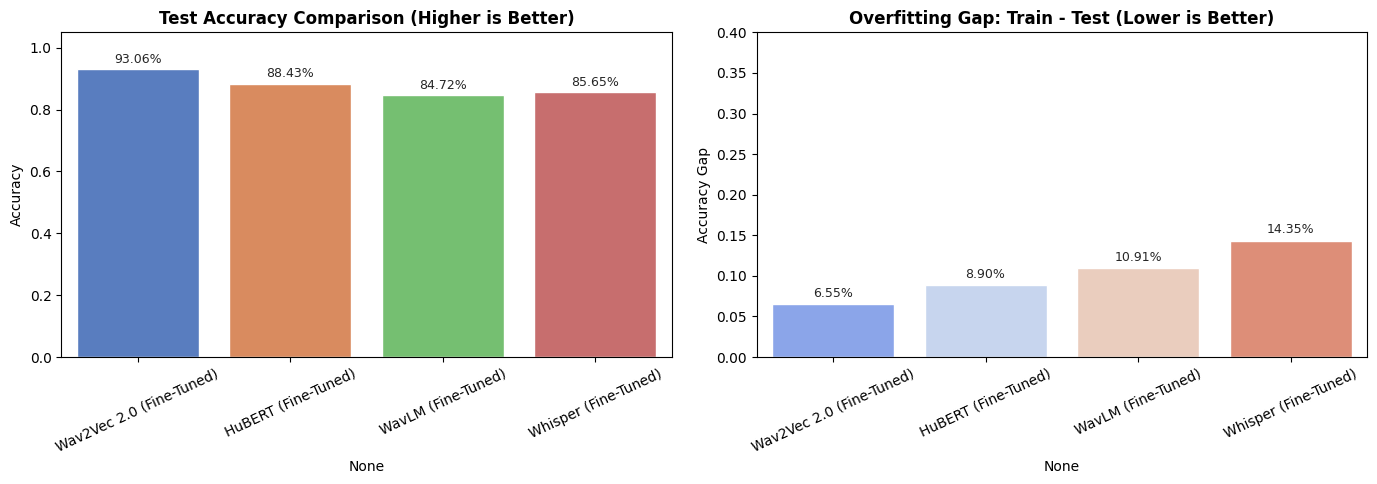

In [10]:
# Convert the results dictionary into a Pandas DataFrame
comparison_df = pd.DataFrame(results).T

if not comparison_df.empty:
    # Rename columns for presentation
    comparison_df = comparison_df.rename(columns={
        "train_acc": "Train Accuracy",
        "test_acc": "Test Accuracy",
        "gap": "Train-Test Gap"
    })
    
    # Print the Leaderboard Table
    print("====================================================================")
    print("                        MODEL LEADERBOARD")
    print("====================================================================")
    display(comparison_df.round(4))
    print("\n")
    
    # Create Accuracy and Overfitting Gap Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="whitegrid")
    
    # Plot 1: Test Accuracy Comparison (Higher is Better)
    bars1 = sns.barplot(
        x=comparison_df.index, 
        y=comparison_df["Test Accuracy"], 
        ax=axes[0], 
        palette="muted"
    )
    axes[0].set_title("Test Accuracy Comparison (Higher is Better)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=25)
    
    # Add values on top of the bars
    for bar in bars1.patches:
        val = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2, 
            val + 0.01, 
            f"{val:.2%}", 
            ha="center", 
            va="bottom", 
            fontsize=9
        )
        
    # Plot 2: Overfitting Gap (Lower is Better)
    bars2 = sns.barplot(
        x=comparison_df.index, 
        y=comparison_df["Train-Test Gap"], 
        ax=axes[1], 
        palette="coolwarm"
    )
    axes[1].set_title("Overfitting Gap: Train - Test (Lower is Better)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Accuracy Gap")
    axes[1].set_ylim(min(0, comparison_df["Train-Test Gap"].min() - 0.05), max(0.4, comparison_df["Train-Test Gap"].max() + 0.05))
    axes[1].tick_params(axis='x', rotation=25)
    
    # Add values on top of the bars
    for bar in bars2.patches:
        val = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2, 
            val + 0.005 if val >= 0 else val - 0.015, 
            f"{val:.2%}", 
            ha="center", 
            va="bottom" if val >= 0 else "top", 
            fontsize=9
        )
        
    plt.tight_layout()
    plt.show()
else:
    print("No results found in the 'results' dictionary yet. Please run and evaluate at least one model.")